# 1. 機械学習とは何かを知る

以下のコードは、学習時間とテストの点数からなるサンプルデータを作成し、pandasのデータフレームとして表示するものです。

まず、学習時間を表す「study_hours」と、テストの点数を表す「score」をそれぞれリストとして用意しています。ここでは、学習時間が1時間から10時間まで増えるにつれて、点数も徐々に高くなるようなデータを設定しています。

次に、これらのデータをpandasのデータフレームに変換しています。データフレームにすることで、表形式でデータを扱ったり、後から平均値や相関関係などを計算したりすることができます。最後にデータフレームの内容を表示して、作成したデータを確認しています。

このデータは、次の段階で学習時間と点数の関係を分析するためのサンプルとして利用できます。


In [1]:
import pandas as pd

df = pd.read_csv("study_scores.csv")

print(df)

    study_hours  score
0           1.2     43
1           8.7     86
2           4.5     57
3           6.3     72
4           2.8     48
..          ...    ...
94          8.9     88
95          5.2     62
96          3.4     51
97          7.8     80
98          9.6     93

[99 rows x 2 columns]


以下のコードは、学習時間とテストの点数の関係を散布図として表示するものです。

まず、横軸に学習時間、縦軸にテストの点数を指定して、データを散布図として描画しています。散布図では、1つの点が「ある学習時間と、そのときのテスト点数」の組み合わせを表します。そのため、2つの変数の間にどのような関係があるのかを視覚的に確認できます。

さらに、グラフのタイトルと横軸・縦軸のラベルを設定しています。最後にグラフを表示することで、学習時間が増えるにつれて点数がどのように変化しているのかを確認できます。

このような散布図は、2つの数値データの関係を調べるときに利用され、後から相関係数などを計算して、両者の関係をより定量的に分析することもできます。


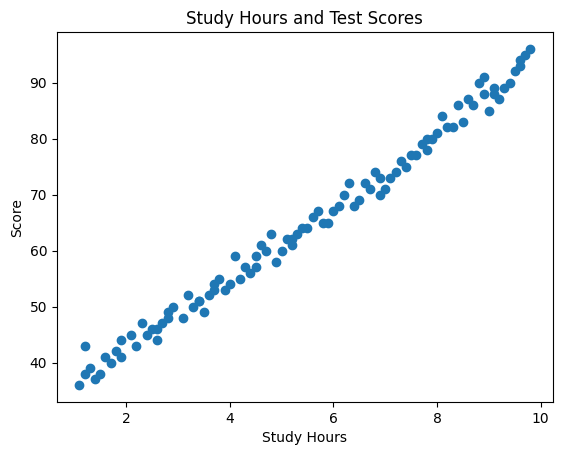

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df["study_hours"], df["score"])

plt.title("Study Hours and Test Scores")
plt.xlabel("Study Hours")
plt.ylabel("Score")

plt.show()

# 2. 学習用データと評価用データに分ける

以下のコードは、学習時間とテストの点数のデータを、機械学習モデルの学習に使用するデータと、モデルの性能を評価するためのデータに分割するものです。

まず、入力データとして「study_hours」を、予測したい目的データとして「score」を指定しています。ここでは、学習時間からテストの点数を予測することを想定しています。

次に、train_test_splitを使ってデータを学習用とテスト用に分割しています。test_sizeを0.2に設定しているため、全体の20％がテスト用、残りの80％が学習用になります。random_stateを指定することで、同じデータを同じ条件で分割できるようにしています。

最後に、学習用データとテスト用データの内容を表示しています。このように、機械学習では、モデルを作るためのデータと、作成したモデルが未知のデータに対してどの程度正しく予測できるかを確認するためのデータを分けて使用します。


In [3]:
from sklearn.model_selection import train_test_split

# Input data
X = df[["study_hours"]]

# Target data
y = df["score"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:")
print(X_train)

print("Test data:")
print(X_test)

Training data:
    study_hours
49          5.7
70          7.2
68          5.8
15          9.6
39          2.9
..          ...
60          3.8
71          9.7
14          5.2
92          6.9
51          3.1

[79 rows x 1 columns]
Test data:
    study_hours
62          9.0
40          8.5
95          5.2
18          1.5
97          7.8
84          2.8
64          4.3
42          3.5
10          6.9
0           1.2
31          8.1
76          8.6
47          6.8
26          9.3
44          9.2
4           2.8
22          6.1
12          8.3
88          7.0
73          4.6


# 3. データからモデルをつくる

以下のコードは、学習時間からテストの点数を予測するための線形回帰モデルを作成し、学習用データを使ってモデルを学習させるものです。

まず、scikit-learnからLinearRegressionを読み込み、線形回帰モデルを作成しています。線形回帰は、入力データと予測したい値の関係を直線で表し、その関係をもとに未知のデータを予測する機械学習手法です。

次に、先ほど用意した学習用データをモデルに与えて学習させています。ここでは、学習時間とテストの点数の関係をモデルが学習し、学習時間から点数を予測するための直線を求めています。

最後に、学習が完了したことを画面に表示しています。この段階ではまだ予測を行っておらず、次の段階でテスト用データをモデルに入力して、点数を予測することができます。


In [4]:
from sklearn.linear_model import LinearRegression

# Create a model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


# 4. モデルを使って予測する

以下のコードは、学習した線形回帰モデルを使って、テスト用データのテスト点数を予測するものです。

まず、テスト用の学習時間をモデルに入力し、それぞれの学習時間に対する予測点数を計算しています。予測結果は「y_pred」に保存されます。ここでは、モデルが学習した学習時間と点数の関係を使って、まだ学習に使用していないデータの点数を予測しています。

その後、実際の点数と予測した点数をそれぞれ表示しています。実際の点数と予測値を並べて比較することで、モデルがどの程度正確に予測できているのかを確認できます。

このように、機械学習では「学習」だけで終わるのではなく、学習に使用していないテストデータを使って予測を行い、実際の値と比較することでモデルの性能を評価します。


In [5]:
# Predict test data
y_pred = model.predict(X_test)

print("Actual scores:")
print(y_test.values)

print("Predicted scores:")
print(y_pred)

Actual scores:
[85 83 62 38 80 49 57 49 70 43 84 87 74 89 87 48 68 82 71 61]
Predicted scores:
[87.79928318 84.53344892 62.97894281 38.81176928 79.96128096 47.30293836
 57.10044114 51.87510632 74.08277929 36.85226872 81.92078151 85.18661577
 73.42961244 89.75878374 89.10561689 47.30293836 68.85744447 83.22711522
 74.73594614 59.05994169]


# 5. 予測結果を確認する

以下のコードは、テストデータの実際の点数と、線形回帰モデルによって予測された点数を1つのデータフレームにまとめるものです。

まず、pandasのデータフレームを作成し、「Actual」列に実際の点数、「Predicted」列にモデルが予測した点数を格納しています。これにより、それぞれのデータについて実際の値と予測値を横に並べて確認できるようになります。

最後に、作成したデータフレームを表示しています。実際の点数と予測された点数を比較することで、予測が実際の値にどの程度近いのかを確認できます。

このように、予測結果を表形式にまとめておくと、モデルの予測結果を確認しやすくなります。また、この結果をもとに、後から平均絶対誤差（MAE）や平均二乗誤差（MSE）などの評価指標を計算することもできます。


In [6]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result)

    Actual  Predicted
0       85  87.799283
1       83  84.533449
2       62  62.978943
3       38  38.811769
4       80  79.961281
5       49  47.302938
6       57  57.100441
7       49  51.875106
8       70  74.082779
9       43  36.852269
10      84  81.920782
11      87  85.186616
12      74  73.429612
13      89  89.758784
14      87  89.105617
15      48  47.302938
16      68  68.857444
17      82  83.227115
18      71  74.735946
19      61  59.059942


以下のコードは、テストデータの実際の点数と、線形回帰モデルが予測した点数を散布図として表示するものです。

横軸には実際の点数、縦軸にはモデルが予測した点数を設定しています。散布図の1つの点は、それぞれのテストデータについて「実際の点数」と「予測された点数」の組み合わせを表しています。

実際の点数と予測値が近いほど、点は対角線方向に集まる傾向があります。そのため、このグラフを見ることで、予測値が実際の値にどの程度近いのかを視覚的に確認できます。

このように、実測値と予測値を散布図で比較することで、機械学習モデルの予測結果を直感的に評価できます。


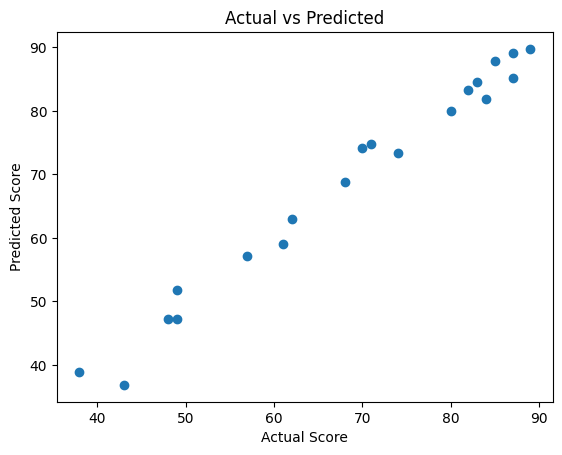

In [7]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")

plt.show()

以下のコードは、線形回帰モデルによる予測結果を、平均絶対誤差（MAE）という評価指標を使って評価するものです。

まず、scikit-learnのmean_absolute_errorを読み込み、実際の点数と予測した点数を渡してMAEを計算しています。MAEは、実際の値と予測値の差を絶対値として求め、その平均を計算したものです。そのため、値が小さいほど予測値が実際の値に近く、モデルの予測誤差が小さいことを意味します。

ここでは、テストデータの実際の点数と予測値を使ってMAEを計算しています。例えば、MAEが「3.0」であれば、モデルの予測値は平均すると実際の点数から約3点離れていると解釈できます。

このように、散布図による視覚的な確認に加えて、MAEのような評価指標を使うことで、モデルの予測精度を数値として評価できます。


In [8]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.8425149791072726


以下のコードは、学習済みの線形回帰モデルに新しい学習時間を入力し、その場合のテストの点数を予測するものです。

まず、新しいデータとして学習時間「7.5時間」をデータフレームにしています。これは、モデルの学習には使用していない新しい入力データとして扱われます。

次に、このデータを学習済みのモデルに入力して、予測されるテストの点数を計算しています。予測結果は「predicted_score」に保存され、最後に学習時間と予測された点数を表示しています。

このように、機械学習モデルを一度学習させておけば、学習に使用していない新しいデータを入力して、その結果を予測することができます。これが機械学習における「予測」の基本的な流れです。


In [9]:
new_data = pd.DataFrame({
    "study_hours": [7.5]
})

predicted_score = model.predict(new_data)

print("Study hours:", new_data["study_hours"].iloc[0])
print("Predicted score:", predicted_score[0])

Study hours: 7.5
Predicted score: 78.00178040220048
